# 🚢 Stage 5: Titanic Survival — Gold Standard
### ML Roadmap — Feature Engineering & Hyperparameter Tuning Project


## Step 0: Install & Import Libraries

In [2]:
# !pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.linear_model   import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm            import SVC
from sklearn.preprocessing  import StandardScaler, OneHotEncoder
from sklearn.compose        import ColumnTransformer
from sklearn.pipeline       import Pipeline
from sklearn.impute         import SimpleImputer
from sklearn.metrics        import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42; np.random.seed(SEED)

print('✅ All libraries imported')
import sklearn; print(f'   Scikit-learn: {sklearn.__version__}')

✅ All libraries imported
   Scikit-learn: 1.8.0


---
## Step 1: Generate & Load the Titanic Dataset

In [3]:
def generate_titanic(n=891, seed=42):
    """
    Realistic synthetic Titanic dataset.
    Same column structure as Kaggle's titanic.csv:
    PassengerId, Survived, Pclass, Name, Sex, Age,
    SibSp, Parch, Ticket, Fare, Cabin, Embarked
    """
    np.random.seed(seed)

    pclass   = np.random.choice([1,2,3], n, p=[0.242,0.212,0.546])
    sex      = np.random.choice(['male','female'], n, p=[0.647,0.353])
    age_base = np.where(sex=='male',
                   np.clip(np.random.normal(30,13,n),0.5,74),
                   np.clip(np.random.normal(27,13,n),0.5,63)).round(1)
    sibsp    = np.random.choice([0,1,2,3,4,5,8], n, p=[0.682,0.234,0.031,0.019,0.019,0.009,0.006])
    parch    = np.random.choice([0,1,2,3,4,5,6], n, p=[0.760,0.132,0.090,0.005,0.004,0.004,0.005])
    fare     = np.where(pclass==1,
                   np.clip(np.random.lognormal(4.5,0.8,n),26,512),
                   np.where(pclass==2,
                       np.clip(np.random.normal(21,10,n),10,73),
                       np.clip(np.random.normal(13,9,n),0,56))).round(4)
    has_cabin = np.random.choice([0,1], n, p=[0.771,0.229])
    cab_let   = ['A','B','C','D','E','F','G']
    cabin     = [f'{np.random.choice(cab_let)}{np.random.randint(10,150)}' if h else ''
                 for h in has_cabin]
    embarked  = np.random.choice(['S','C','Q'], n, p=[0.724,0.188,0.088]).astype(object)
    embarked[np.random.choice(n,2,replace=False)] = np.nan

    t_male  = ['Mr.','Mr.','Mr.','Mr.','Mr.','Mr.','Mr.','Dr.','Rev.','Col.']
    t_fem   = ['Mrs.','Mrs.','Mrs.','Miss.','Miss.','Miss.','Miss.','Miss.','Dr.','Lady.']
    m_first = ['James','John','William','Thomas','George','Robert','Charles','Arthur','Henry','Edward']
    f_first = ['Mary','Annie','Margaret','Elizabeth','Ellen','Alice','Sarah','Emma','Florence','Edith']
    last_n  = ['Smith','Johnson','Williams','Brown','Jones','Miller','Davis','Wilson','Taylor','Anderson']
    names = []
    for i in range(n):
        ln = np.random.choice(last_n)
        if sex[i]=='male':
            names.append(f'{ln}, {np.random.choice(t_male)} {np.random.choice(m_first)}')
        else:
            names.append(f'{ln}, {np.random.choice(t_fem)} {np.random.choice(f_first)}')

    # Realistic survival probabilities (women + 1st class + children prioritised)
    surv_prob = np.clip(
        0.20 + 0.45*(sex=='female') + 0.20*(pclass==1) + 0.05*(pclass==2)
        - 0.10*(age_base>60) + 0.15*(age_base<15)
        - 0.05*(sibsp>2) - 0.05*(parch>2)
        + 0.10*(pclass==1)*(sex=='female')
        + np.random.normal(0,0.10,n), 0.02, 0.98)
    survived = (np.random.uniform(0,1,n) < surv_prob).astype(int)

    # Missing values — ~20% age, 2 embarked (mirroring real dataset)
    age = age_base.astype(object)
    age[np.random.choice(n,int(n*0.198),replace=False)] = np.nan

    return pd.DataFrame({
        'PassengerId': range(1,n+1), 'Survived': survived, 'Pclass': pclass,
        'Name': names, 'Sex': sex, 'Age': age, 'SibSp': sibsp, 'Parch': parch,
        'Ticket': [f'{np.random.randint(10000,999999)}' for _ in range(n)],
        'Fare': fare, 'Cabin': cabin, 'Embarked': embarked
    })


df = generate_titanic()
# df.to_csv('titanic.csv', index=False)

# OR load from CSV:
df = pd.read_csv('titanic.csv')
df['Cabin'] = df['Cabin'].replace('', np.nan)

print(f'✅ Dataset loaded: {df.shape[0]} passengers × {df.shape[1]} columns')
print(f'   Survival rate  : {df["Survived"].mean():.3f} (real Titanic: 0.384)')
print(f'   Missing Age    : {df["Age"].isna().sum()} ({df["Age"].isna().mean()*100:.0f}%)')
print(f'   Missing Cabin  : {(df["Cabin"]=="").sum()} ({(df["Cabin"]=="").mean()*100:.0f}%)')
print(f'   Missing Embarked: {df["Embarked"].isna().sum()}')
df.head(6)

✅ Dataset loaded: 891 passengers × 12 columns
   Survival rate  : 0.469 (real Titanic: 0.384)
   Missing Age    : 176 (20%)
   Missing Cabin  : 0 (0%)
   Missing Embarked: 2


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,2,"Johnson, Mrs. Emma",female,27.4,0,0,718985,18.2249,NaN,S
1,2,1,3,"Wilson, Miss. Emma",female,12.9,0,0,701323,6.5113,D62,C
2,3,1,3,"Davis, Mr. George",male,39.6,0,2,921439,38.0197,NaN,S
3,4,1,3,"Anderson, Miss. Margaret",female,35.8,0,0,253244,3.6581,NaN,S
4,5,1,1,"Smith, Mr. Edward",male,46.9,0,0,150251,55.8612,NaN,S
5,6,1,1,"Wilson, Rev. Charles",male,50.3,0,0,890872,70.8563,NaN,S


---
## Step 2: EDA — Understanding Survival Patterns

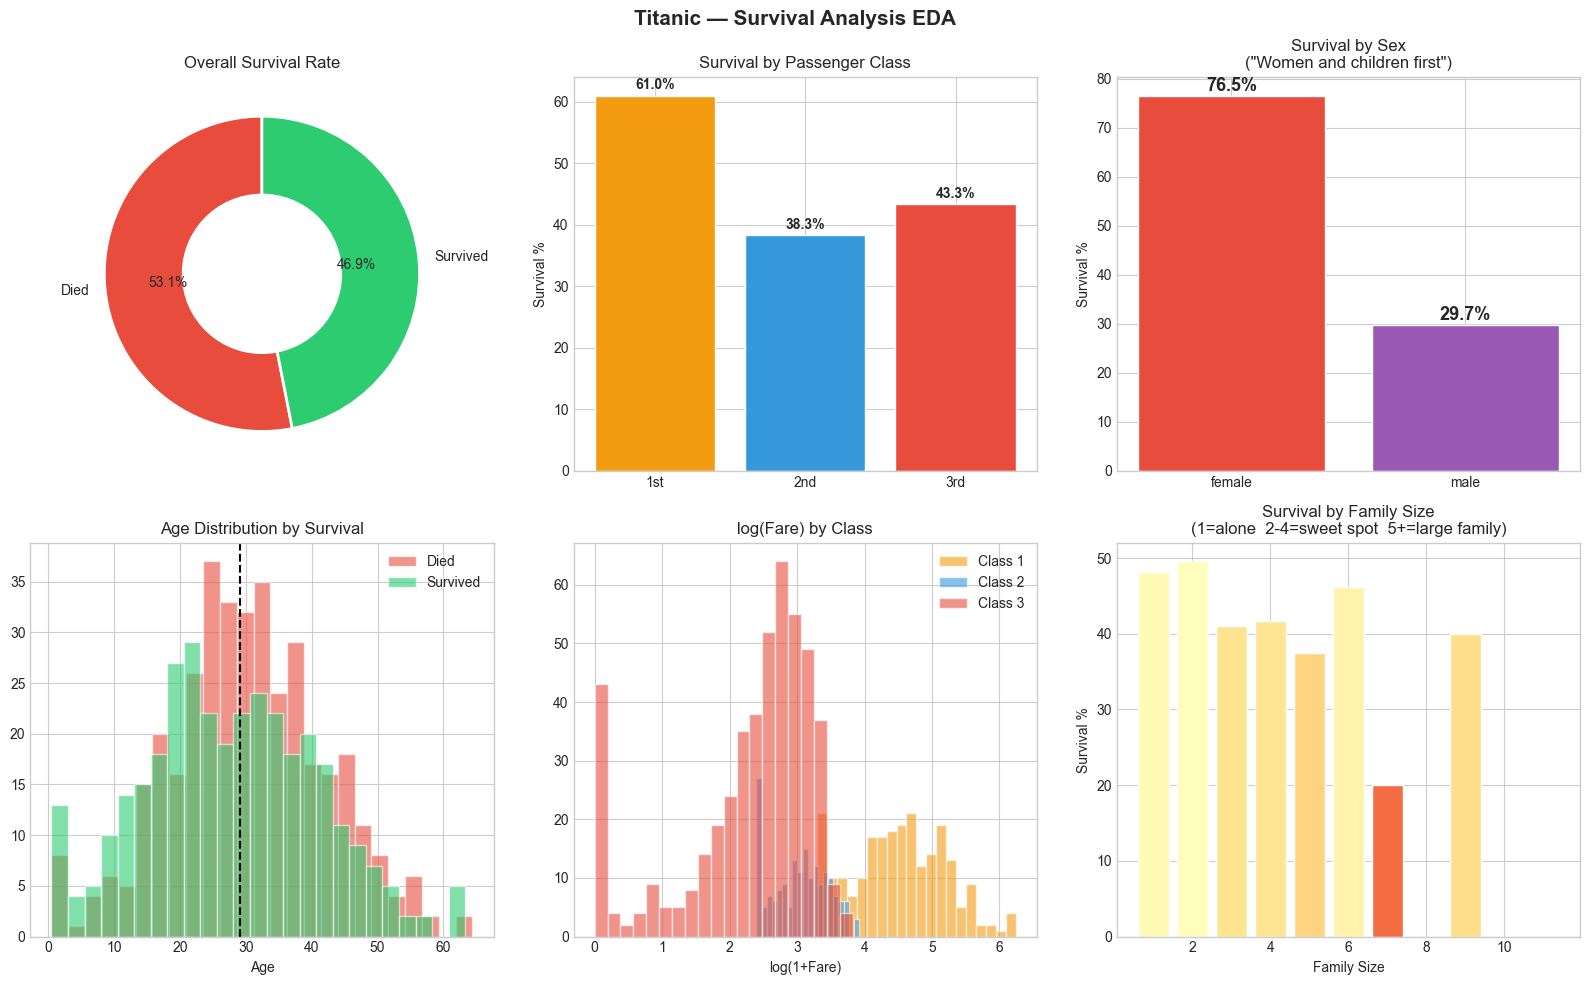

💾 Saved: tt_01_eda.png


In [ ]:
df['Cabin'] = df['Cabin'].replace('', np.nan)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Titanic — Survival Analysis EDA', fontsize=15, fontweight='bold')

# 1. Overall survival donut
sv = df['Survived'].value_counts().sort_index()
axes[0,0].pie(sv.values, labels=['Died','Survived'], autopct='%1.1f%%',
              colors=['#e74c3c','#2ecc71'],
              wedgeprops=dict(width=0.5,edgecolor='white',linewidth=2), startangle=90)
axes[0,0].set_title('Overall Survival Rate')

# 2. By Pclass
pc_surv = df.groupby('Pclass')['Survived'].mean()*100
bars = axes[0,1].bar(['1st','2nd','3rd'], pc_surv.values,
                     color=['#f39c12','#3498db','#e74c3c'], edgecolor='white')
axes[0,1].set_title('Survival by Passenger Class')
axes[0,1].set_ylabel('Survival %')
for bar, v in zip(bars, pc_surv.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, v+1, f'{v:.1f}%',
                   ha='center', fontweight='bold')

# 3. By Sex
sex_surv = df.groupby('Sex')['Survived'].mean()*100
bars2 = axes[0,2].bar(sex_surv.index, sex_surv.values,
                      color=['#e74c3c','#9b59b6'], edgecolor='white')
axes[0,2].set_title('Survival by Sex\n("Women and children first")')
axes[0,2].set_ylabel('Survival %')
for bar,v in zip(bars2,sex_surv.values):
    axes[0,2].text(bar.get_x()+bar.get_width()/2, v+1,
                   f'{v:.1f}%', ha='center', fontweight='bold', fontsize=13)

# 4. Age by survival
for sv_val,c,l in [(0,'#e74c3c','Died'),(1,'#2ecc71','Survived')]:
    d = df[df['Survived']==sv_val]['Age'].dropna().astype(float)
    axes[1,0].hist(d, bins=25, alpha=0.6, color=c, edgecolor='white', label=l)
axes[1,0].set_title('Age Distribution by Survival')
axes[1,0].set_xlabel('Age'); axes[1,0].legend()
axes[1,0].axvline(df['Age'].dropna().astype(float).median(),
                  color='black', ls='--', lw=1.5, label='Median Age')

for cls,c in [(1,'#f39c12'),(2,'#3498db'),(3,'#e74c3c')]:
    axes[1,1].hist(np.log1p(df[df['Pclass']==cls]['Fare']), bins=20,
                   alpha=0.6, color=c, edgecolor='white', label=f'Class {cls}')
axes[1,1].set_title('log(Fare) by Class')
axes[1,1].set_xlabel('log(1+Fare)'); axes[1,1].legend()


fam_surv = df.groupby('FamilySize')['Survived'].mean()*100
axes[1,2].bar(fam_surv.index, fam_surv.values,
              color=plt.cm.RdYlGn(fam_surv.values/100), edgecolor='white')
axes[1,2].set_title('Survival by Family Size\n(1=alone  2-4=sweet spot  5+=large family)')
axes[1,2].set_xlabel('Family Size'); axes[1,2].set_ylabel('Survival %')

plt.tight_layout()
plt.savefig('tt_01_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: tt_01_eda.png')

---
## Step 3: Deep Feature Engineering

In [ ]:
def engineer_features(raw):
    """
    Complete feature engineering pipeline for Titanic.
    Input : raw DataFrame (12 columns)- 👉 Titanic raw data (12 columns) எடுத்துக்கொண்டு
    Output: enriched DataFrame (26 columns) - 👉 smart features (26 columns) ஆக மாற்றுகிறது
    """
    d = raw.copy() #original data copy எடுக்கிறது
    d['Cabin'] = d['Cabin'].replace('', np.nan) #empty cabin → NaN ஆ மாற்றுகிறது

    # ── 1. TITLE from Name ──────────────────────────────────────────────────
    # Extract text between ', ' and '.'
    d['Title'] = d['Name'].astype(str).str.extract(r',\s*([^\.]+)\.')
    d['Title'] = d['Title'].str.strip()
    # Group rare titles
    rare_titles = d['Title'].value_counts()
    d['Title'] = d['Title'].where(~d['Title'].isin(rare_titles[rare_titles < 8].index), 'Rare')
    # Standardise female titles
    d['Title'] = d['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs','Lady':'Mrs','Dona':'Mrs'})

    # ── 2. FAMILY features ──────────────────────────────────────────────────
    d['FamilySize']  = d['SibSp'] + d['Parch'] + 1
    d['IsAlone']     = (d['FamilySize'] == 1).astype(int)
    d['SmallFamily'] = (d['FamilySize'].between(2, 4)).astype(int)
    d['LargeFamily'] = (d['FamilySize'] > 4).astype(int)

    # ── 3. CABIN features ───────────────────────────────────────────────────
    d['HasCabin']  = d['Cabin'].notna().astype(int) # cabin இருக்கா இல்லையா
    d['CabinDeck'] = d['Cabin'].astype(str).str[0]  # A/B/C/D/E/F/G or 'n' (nan)
    d['CabinDeck'] = d['CabinDeck'].replace('n', 'U')  # U = Unknown (n → U)

    # ── 4. FARE features ────────────────────────────────────────────────────
    d['FareLog']  = np.log1p(d['Fare'])
    fare_q = d['Fare'].quantile([0.25, 0.5, 0.75]).values
    d['FareBand'] = pd.cut(d['Fare'],
        bins=[-1] + list(fare_q) + [9999],
        labels=['Low','Mid','High','VHigh']).astype(str)

    # ── 5. AGE features (impute per title, then band) ────────────────────────
    # Impute missing age using the median age of passengers with the same title
    # This is much better than global median!
    for title in d['Title'].dropna().unique():
        title_median = d.loc[d['Title']==title, 'Age'].dropna().astype(float).median()
        if pd.isna(title_median):
            title_median = d['Age'].dropna().astype(float).median()
        mask = (d['Title'] == title) & d['Age'].isna()
        d.loc[mask, 'Age'] = title_median
    d['Age'] = d['Age'].fillna(d['Age'].dropna().astype(float).median()).astype(float)

    d['AgeBand']  = pd.cut(d['Age'], bins=[0,12,18,35,60,100],
        labels=['Child','Teen','Young','Middle','Senior']).astype(str)
    d['IsChild']  = (d['Age'] < 12).astype(int)
    d['IsSenior'] = (d['Age'] > 60).astype(int)

    # ── 6. INTERACTION features ─────────────────────────────────────────────
    d['Sex_Pclass']     = d['Sex'].astype(str) + '_' + d['Pclass'].astype(str) #combination feature = stronger signal
    d['IsWomanOrChild'] = ((d['Sex']=='female') | (d['Age']<15)).astype(int) # women & children first

    # ── 7. EMBARKED fill ────────────────────────────────────────────────────
    d['Embarked'] = d['Embarked'].fillna('S')

    return d


df_fe = engineer_features(df)
df_fe.to_csv('titanic_feature_engineered.csv', index=False)

new_cols = [c for c in df_fe.columns if c not in df.columns]
print(f'✅ Feature engineering complete')
print(f'   Original columns : {df.shape[1]}')
print(f'   Engineered columns: {df_fe.shape[1]}')
print(f'   New features added: {len(new_cols)}')
print(f'\n   New features: {new_cols}')
df_fe[['Name','Title', 'IsAlone', 'SmallFamily', 'LargeFamily', 'HasCabin', 'CabinDeck', 'FareLog', 'FareBand', 'AgeBand', 'IsChild', 'IsSenior', 'Sex_Pclass', 'IsWomanOrChild']].head(10)


✅ Feature engineering complete
   Original columns : 13
   Engineered columns: 26
   New features added: 13

   New features: ['Title', 'IsAlone', 'SmallFamily', 'LargeFamily', 'HasCabin', 'CabinDeck', 'FareLog', 'FareBand', 'AgeBand', 'IsChild', 'IsSenior', 'Sex_Pclass', 'IsWomanOrChild']


,Name,Title,IsAlone,SmallFamily,LargeFamily,HasCabin,CabinDeck,FareLog,FareBand,AgeBand,IsChild,IsSenior,Sex_Pclass,IsWomanOrChild
0,"Johnson, Mrs. Emma",Mrs,1,0,0,0,NaN,2.956206,Mid,Young,0,0,female_2,1
1,"Wilson, Miss. Emma",Miss,1,0,0,1,D,2.016409,Low,Teen,0,0,female_3,1
2,"Davis, Mr. George",Mr,0,1,0,0,NaN,3.664067,VHigh,Middle,0,0,male_3,0
3,"Anderson, Miss. Margaret",Miss,1,0,0,0,NaN,1.538608,Low,Middle,0,0,female_3,1
4,"Smith, Mr. Edward",Mr,1,0,0,0,NaN,4.040613,VHigh,Middle,0,0,male_1,0
5,"Wilson, Rev. Charles",Rev,1,0,0,0,NaN,4.274668,VHigh,Middle,0,0,male_1,0
6,"Smith, Mrs. Mary",Mrs,0,1,0,0,NaN,5.152935,VHigh,Young,0,0,female_1,1
7,"Johnson, Mr. Thomas",Mr,0,1,0,1,B,2.475067,Mid,Young,0,0,male_3,0
8,"Anderson, Rev. Thomas",Rev,1,0,0,0,NaN,3.505930,High,Middle,0,0,male_3,0
9,"Brown, Mr. Henry",Mr,0,1,0,0,NaN,0.000000,Low,Young,0,0,male_3,0


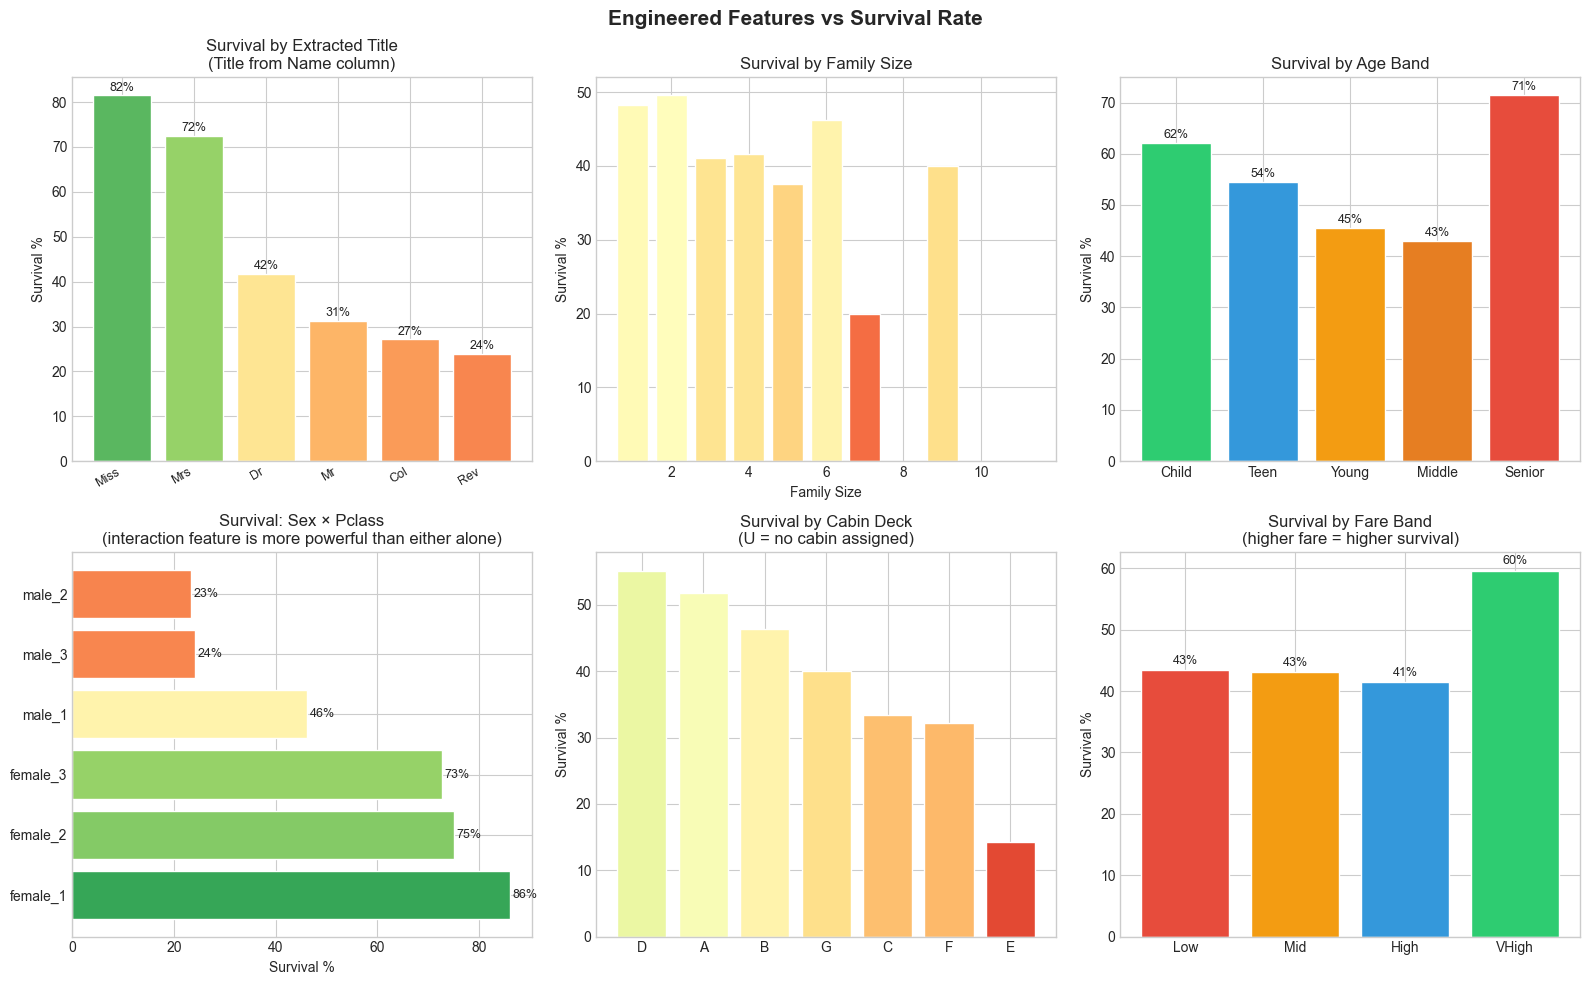

💾 Saved: tt_02_engineered_features.png


In [6]:
# Visualise engineered feature survival rates
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Engineered Features vs Survival Rate', fontsize=15, fontweight='bold')

# 1. Title
title_surv = df_fe.groupby('Title')['Survived'].mean().sort_values(ascending=False)*100
bars = axes[0,0].bar(range(len(title_surv)), title_surv.values,
                     color=plt.cm.RdYlGn(title_surv.values/100), edgecolor='white')
axes[0,0].set_xticks(range(len(title_surv)))
axes[0,0].set_xticklabels(title_surv.index, rotation=30, ha='right', fontsize=9)
axes[0,0].set_title('Survival by Extracted Title\n(Title from Name column)')
axes[0,0].set_ylabel('Survival %')
for bar,v in zip(bars, title_surv.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, v+1,
                   f'{v:.0f}%', ha='center', fontsize=9)

# 2. Family size
fam_surv = df_fe.groupby('FamilySize')['Survived'].mean()*100
axes[0,1].bar(fam_surv.index, fam_surv.values,
              color=plt.cm.RdYlGn(fam_surv.values/100), edgecolor='white')
axes[0,1].set_title('Survival by Family Size')
axes[0,1].set_xlabel('Family Size'); axes[0,1].set_ylabel('Survival %')

# 3. Age band
ab_ord  = ['Child','Teen','Young','Middle','Senior']
ab_surv = df_fe.groupby('AgeBand')['Survived'].mean()*100
ab_vals = [ab_surv.get(b,0) for b in ab_ord]
axes[0,2].bar(ab_ord, ab_vals,
              color=['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c'], edgecolor='white')
axes[0,2].set_title('Survival by Age Band')
axes[0,2].set_ylabel('Survival %')
for i,v in enumerate(ab_vals): axes[0,2].text(i, v+1, f'{v:.0f}%', ha='center', fontsize=9)

# 4. Sex × Pclass interaction 
sp_surv = df_fe.groupby('Sex_Pclass')['Survived'].mean().sort_values(ascending=False)*100
axes[1,0].barh(sp_surv.index, sp_surv.values,
               color=plt.cm.RdYlGn(sp_surv.values/100), edgecolor='white')
axes[1,0].set_title('Survival: Sex × Pclass\n(interaction feature is more powerful than either alone)')
axes[1,0].set_xlabel('Survival %')
for i,v in enumerate(sp_surv.values):
    axes[1,0].text(v+0.5, i, f'{v:.0f}%', va='center', fontsize=9)

# 5. Cabin deck
deck_surv = df_fe.groupby('CabinDeck')['Survived'].mean().sort_values(ascending=False)*100
axes[1,1].bar(deck_surv.index, deck_surv.values,
              color=plt.cm.RdYlGn(deck_surv.values/100), edgecolor='white')
axes[1,1].set_title('Survival by Cabin Deck\n(U = no cabin assigned)')
axes[1,1].set_ylabel('Survival %')

# 6. Fare band
fb_ord  = ['Low','Mid','High','VHigh']
fb_surv = df_fe.groupby('FareBand')['Survived'].mean()*100
fb_vals = [fb_surv.get(b,0) for b in fb_ord]
axes[1,2].bar(fb_ord, fb_vals,
              color=['#e74c3c','#f39c12','#3498db','#2ecc71'], edgecolor='white')
axes[1,2].set_title('Survival by Fare Band\n(higher fare = higher survival)')
axes[1,2].set_ylabel('Survival %')
for i,v in enumerate(fb_vals): axes[1,2].text(i, v+1, f'{v:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('tt_02_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: tt_02_engineered_features.png')

## Step 4: Build the Preprocessing Pipeline & Split Data

In [ ]:

NUM_FEATS = [
    'Age','Fare','FareLog','FamilySize','SibSp','Parch',
    'IsAlone','SmallFamily','LargeFamily','HasCabin',
    'IsChild','IsSenior','IsWomanOrChild','Pclass'
]
CAT_FEATS = [
    'Sex','Title','Embarked','AgeBand','FareBand','CabinDeck','Sex_Pclass'
]
TARGET = 'Survived'

X = df_fe[NUM_FEATS + CAT_FEATS] #passenger details
y = df_fe[TARGET] # survival answer

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Preprocessing pipeline
num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')), #Missing values fill.
    ('scale',  StandardScaler())
])

cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')), # Missing category → most common value fill.
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # ML model text புரியாது ❌
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, NUM_FEATS), # Numeric columns → numeric pipeline
    ('cat', cat_pipe, CAT_FEATS) # Categorical columns → categorical pipeline
])

print(f'✅ Features: {len(NUM_FEATS)} numeric + {len(CAT_FEATS)} categorical = {len(NUM_FEATS)+len(CAT_FEATS)} total')
print(f'   Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'   Train survival: {y_train.mean():.3f} | Test survival: {y_test.mean():.3f}  (should match!)')

✅ Features: 14 numeric + 7 categorical = 21 total
   Train: 712 | Test: 179
   Train survival: 0.469 | Test survival: 0.469  (should match!)



## Step 5: Baseline — Compare 5 Models

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED) # Dataset → 5 parts split. ex : Fold 1, Fold 2, Fold 3, Fold 4, Fold 5

baseline_models = {
    'Logistic Reg'  : Pipeline([('pre',preprocessor),('model',LogisticRegression(max_iter=1000,random_state=SEED))]),
    'Decision Tree' : Pipeline([('pre',preprocessor),('model',DecisionTreeClassifier(random_state=SEED))]), 
    'Random Forest' : Pipeline([('pre',preprocessor),('model',RandomForestClassifier(n_estimators=100,random_state=SEED))]), 
    'Grad. Boosting': Pipeline([('pre',preprocessor),('model',GradientBoostingClassifier(random_state=SEED))]), 
    'SVM'           : Pipeline([('pre',preprocessor),('model',SVC(probability=True,random_state=SEED))]), 
}

bl_results = {}
print('━'*70)
print(f'  {"Model":<18} {"CV Accuracy":>12} {"CV Std":>9}  {"Test Acc":>10}')
print('━'*70)

for name, pipe in baseline_models.items():
    cv_scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy') 
    pipe.fit(X_train, y_train) # Model learns Titanic patterns.
    test_acc = accuracy_score(y_test, pipe.predict(X_test)) # Measures final exam score.,  Predicts survey or died
    bl_results[name] = {'cv': cv_scores.mean(), 'cv_std': cv_scores.std(), 'test': test_acc} #Stores all model scores.
    print(f'  {name:<18} {cv_scores.mean():>12.4f} {cv_scores.std():>9.4f}  {test_acc:>10.4f}')

print('━'*70)
best_bl = max(bl_results, key=lambda k: bl_results[k]['cv'])
print(f'\n  Best baseline: {best_bl} (CV={bl_results[best_bl]["cv"]:.4f})')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Model               CV Accuracy    CV Std    Test Acc
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Logistic Reg             0.7071    0.0190      0.6927
  Decision Tree            0.6072    0.0089      0.6034
  Random Forest            0.6846    0.0177      0.6480
  Grad. Boosting           0.6970    0.0162      0.6927
  SVM                      0.7149    0.0111      0.7039
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Best baseline: SVM (CV=0.7149)



## Step 6: GridSearchCV — Exhaustive Hyperparameter Search


In [ ]:
print('🔍 GridSearchCV — Random Forest (48 combinations × 5 folds)...')
print('   This may take 1-3 minutes...')

rf_pipe = Pipeline([
    ('pre',   preprocessor), 
    ('model', RandomForestClassifier(random_state=SEED)) 
])

rf_param_grid = {
    'model__n_estimators'    : [100, 200, 300], 
    'model__max_depth'       : [4, 6, 8, None], 
    'model__min_samples_split': [2, 5], 
    'model__min_samples_leaf' : [1, 2], }

rf_gs = GridSearchCV(
    rf_pipe, rf_param_grid,
    cv=skf, scoring='accuracy', 
    n_jobs=-1, verbose=1, return_train_score=True
)
rf_gs.fit(X_train, y_train) 

rf_best_pred = rf_gs.predict(X_test) 
rf_best_acc  = accuracy_score(y_test, rf_best_pred) 

print(f'\n✅ GridSearchCV complete!')
print(f'   Best CV Accuracy : {rf_gs.best_score_:.4f}')
print(f'   Test Accuracy    : {rf_best_acc:.4f}')
print(f'   Best Parameters  :')
for k, v in rf_gs.best_params_.items():
    print(f'     {k:<30}: {v}')


🔍 GridSearchCV — Random Forest (48 combinations × 5 folds)...
   This may take 1-3 minutes...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

✅ GridSearchCV complete!
   Best CV Accuracy : 0.7401
   Test Accuracy    : 0.7207
   Best Parameters  :
     model__max_depth              : 4
     model__min_samples_leaf       : 1
     model__min_samples_split      : 2
     model__n_estimators           : 300


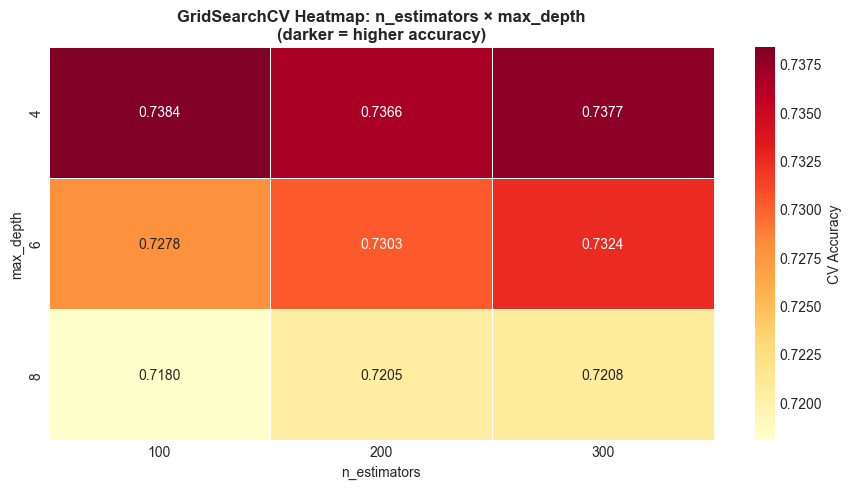

💾 Saved: tt_06_gridsearch_heatmap.png


In [ ]:

# Visualise GridSearch results as heatmap
gs_df    = pd.DataFrame(rf_gs.cv_results_)
piv_data = gs_df.groupby(
    ['param_model__n_estimators','param_model__max_depth']
)['mean_test_score'].mean().reset_index()
piv_data.columns = ['n_estimators','max_depth','score']
piv_data['max_depth'] = piv_data['max_depth'].fillna(999).astype(int).astype(str).replace('999','None')
piv_table = piv_data.pivot(index='max_depth', columns='n_estimators', values='score')

plt.figure(figsize=(9, 5))
sns.heatmap(piv_table, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', cbar_kws={'label':'CV Accuracy'})
plt.title('GridSearchCV Heatmap: n_estimators × max_depth\n(darker = higher accuracy)',
          fontsize=12, fontweight='bold')
plt.xlabel('n_estimators'); plt.ylabel('max_depth')
plt.tight_layout()
plt.savefig('tt_06_gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: tt_06_gridsearch_heatmap.png')


---
## Step 7: RandomizedSearchCV — Faster Exploration


In [ ]:

print('🎲 RandomizedSearchCV — Gradient Boosting (30 random iterations × 5 folds)...')

gb_pipe = Pipeline([
    ('pre',   preprocessor), 
    ('model', GradientBoostingClassifier(random_state=SEED)) 
])

gb_param_distributions = { 
    'model__n_estimators'    : [100, 200, 300, 400],
    'model__learning_rate'   : [0.05, 0.08, 0.10, 0.15, 0.20], # How fast model learns.
    'model__max_depth'       : [3, 4, 5, 6],
    'model__subsample'       : [0.7, 0.8, 0.9, 1.0],
    'model__min_samples_split': [2, 5, 10],
}

gb_rs = RandomizedSearchCV(
    gb_pipe, gb_param_distributions,
    n_iter=30,          
    cv=skf, scoring='accuracy',
    random_state=SEED, n_jobs=-1, verbose=1
)

gb_rs.fit(X_train, y_train)

gb_best_pred = gb_rs.predict(X_test)
gb_best_acc  = accuracy_score(y_test, gb_best_pred)

print(f'\n✅ RandomizedSearchCV complete!')
print(f'   Best CV Accuracy : {gb_rs.best_score_:.4f}')
print(f'   Test Accuracy    : {gb_best_acc:.4f}')
print(f'   Best Parameters  :')
for k, v in gb_rs.best_params_.items():
    print(f'     {k:<35}: {v}')


🎲 RandomizedSearchCV — Gradient Boosting (30 random iterations × 5 folds)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ RandomizedSearchCV complete!
   Best CV Accuracy : 0.7079
   Test Accuracy    : 0.6816
   Best Parameters  :
     model__subsample                   : 1.0
     model__n_estimators                : 200
     model__min_samples_split           : 5
     model__max_depth                   : 3
     model__learning_rate               : 0.05



## Step 8: Final Results — Before vs After Tuning

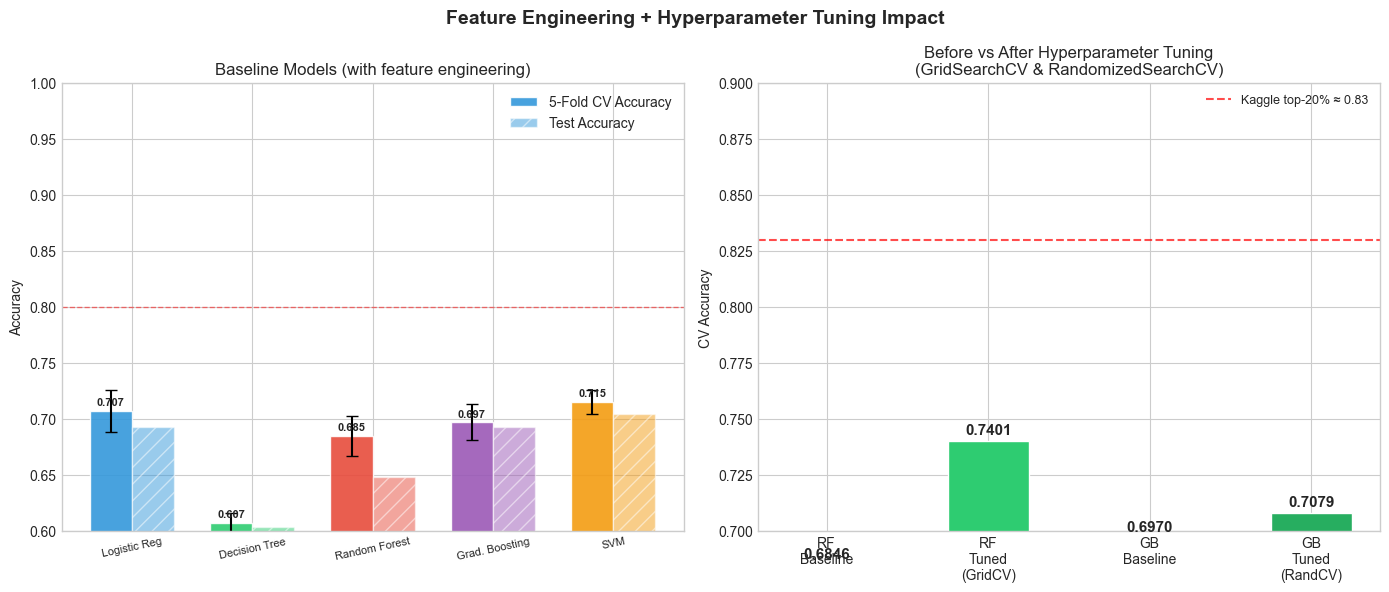

💾 Saved: tt_03_tuning_impact.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature Engineering + Hyperparameter Tuning Impact', fontsize=14, fontweight='bold')

names_b = list(bl_results.keys())
cv_m    = [bl_results[n]['cv']    for n in names_b]
cv_s    = [bl_results[n]['cv_std'] for n in names_b]
te_a    = [bl_results[n]['test']   for n in names_b]
cols5   = ['#3498db','#2ecc71','#e74c3c','#9b59b6','#f39c12']
xp      = np.arange(len(names_b)); w = 0.35

axes[0].bar(xp-w/2, cv_m, w, yerr=cv_s, capsize=4, color=cols5,
            edgecolor='white', alpha=0.9, label='5-Fold CV Accuracy')
axes[0].bar(xp+w/2, te_a, w, color=cols5,
            edgecolor='white', alpha=0.5, hatch='//', label='Test Accuracy')
axes[0].set_title('Baseline Models (with feature engineering)')
axes[0].set_xticks(xp); axes[0].set_xticklabels(names_b, rotation=12, fontsize=8)
axes[0].set_ylim(0.60, 1.0); axes[0].set_ylabel('Accuracy'); axes[0].legend()
axes[0].axhline(0.80, color='red', ls='--', lw=1, alpha=0.5)
for i, v in enumerate(cv_m):
    axes[0].text(xp[i]-w/2, v+0.005, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')

ba_labels = ['RF\nBaseline','RF\nTuned\n(GridCV)','GB\nBaseline','GB\nTuned\n(RandCV)']
ba_vals   = [
    bl_results['Random Forest']['cv'], rf_gs.best_score_,
    bl_results['Grad. Boosting']['cv'], gb_rs.best_score_
]
ba_cols   = ['#e74c3c','#2ecc71','#e67e22','#27ae60']
ba_bars   = axes[1].bar(ba_labels, ba_vals, color=ba_cols, edgecolor='white', width=0.5)
axes[1].set_title('Before vs After Hyperparameter Tuning\n(GridSearchCV & RandomizedSearchCV)')
axes[1].set_ylim(0.70, 0.90); axes[1].set_ylabel('CV Accuracy')
for bar, v in zip(ba_bars, ba_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.003,
                 f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[1].axhline(0.83, color='red', ls='--', lw=1.5, alpha=0.7, label='Kaggle top-20% ≈ 0.83') 
axes[1].legend(fontsize=9)


plt.tight_layout()
plt.savefig('tt_03_tuning_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: tt_03_tuning_impact.png')


---
## Step 9: Learning Curve — Diagnose Bias vs Variance


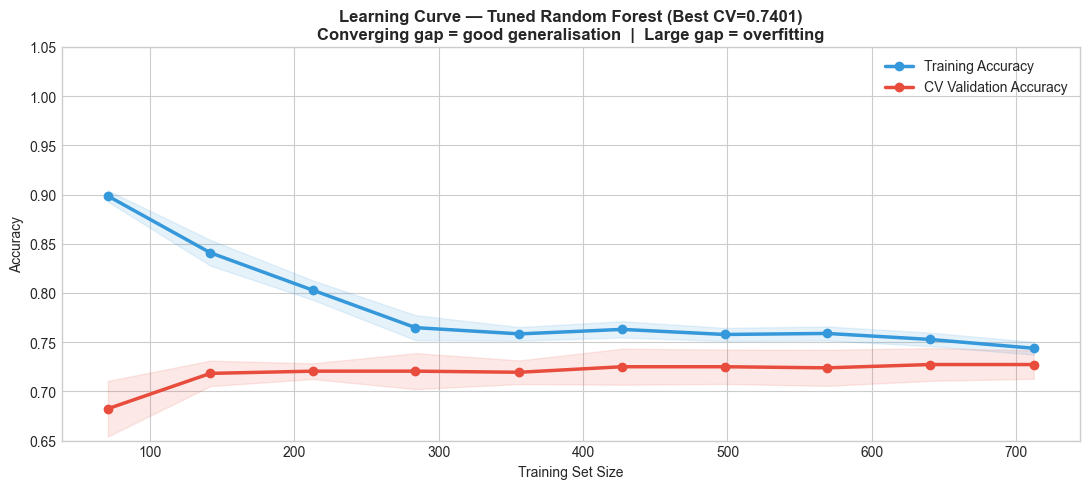

💾 Saved: tt_04_learning_curve.png


In [ ]:

best_estimator = rf_gs.best_estimator_
tr_sizes, tr_scores, va_scores = learning_curve(
    best_estimator, X, y, cv=skf,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', n_jobs=-1
)

plt.figure(figsize=(11, 5))
plt.plot(tr_sizes, tr_scores.mean(1), 'o-', color='#3498db', lw=2.5, label='Training Accuracy') 
plt.plot(tr_sizes, va_scores.mean(1), 'o-', color='#e74c3c', lw=2.5, label='CV Validation Accuracy') 
plt.fill_between(tr_sizes,
    tr_scores.mean(1)-tr_scores.std(1), tr_scores.mean(1)+tr_scores.std(1),
    alpha=0.12, color='#3498db')
plt.fill_between(tr_sizes,
    va_scores.mean(1)-va_scores.std(1), va_scores.mean(1)+va_scores.std(1),
    alpha=0.12, color='#e74c3c')
plt.title(
    f'Learning Curve — Tuned Random Forest (Best CV={rf_gs.best_score_:.4f})\n'
    'Converging gap = good generalisation  |  Large gap = overfitting',
    fontsize=12, fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(fontsize=10)
plt.ylim(0.65, 1.05)
plt.tight_layout()
plt.savefig('tt_04_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: tt_04_learning_curve.png')

---
## Step 10: Feature Importance


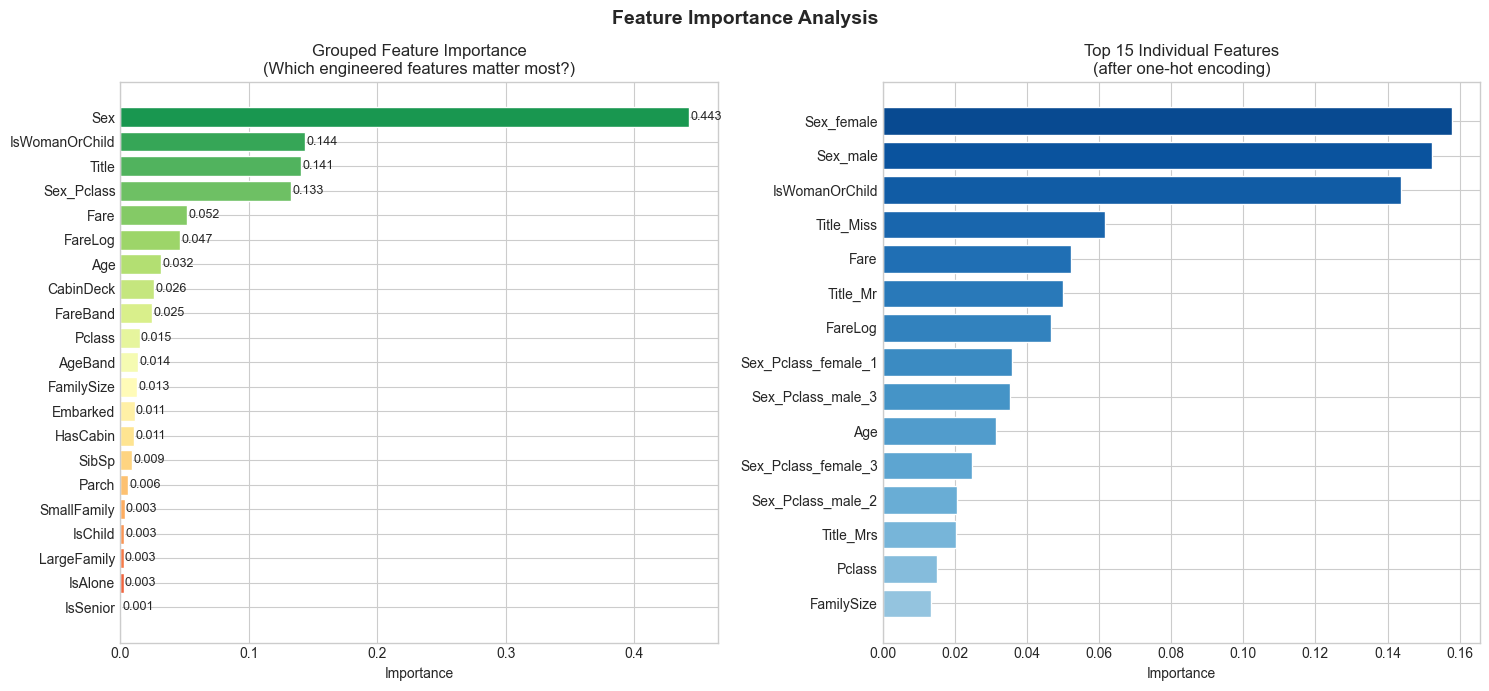

💾 Saved: tt_05_feature_importance.png

🔬 Top 5 most important features for survival:
   Sex                    importance=0.4428
   IsWomanOrChild         importance=0.1437
   Title                  importance=0.1409
   Sex_Pclass             importance=0.1327
   Fare                   importance=0.0522


In [15]:
rf_model = rf_gs.best_estimator_.named_steps['model']
ohe_obj  = rf_gs.best_estimator_.named_steps['pre'].transformers_[1][1].named_steps['ohe']
ohe_names= list(ohe_obj.get_feature_names_out(CAT_FEATS))
all_feats = NUM_FEATS + ohe_names
fi_raw    = pd.Series(rf_model.feature_importances_, index=all_feats)

# Group OHE features back to parent category
grouped = {}
for f in NUM_FEATS: grouped[f] = fi_raw.get(f, 0)
for f in CAT_FEATS:
    cols = [c for c in ohe_names if c.startswith(f+'_')]
    grouped[f] = fi_raw[cols].sum() if cols else 0
g_series = pd.Series(grouped).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')

# Grouped
colors_fi = plt.cm.RdYlGn(np.linspace(0.15, 0.90, len(g_series)))
bars = axes[0].barh(g_series.index, g_series.values, color=colors_fi, edgecolor='white')
for bar, v in zip(bars, g_series.values):
    axes[0].text(v+0.001, bar.get_y()+bar.get_height()/2,
                 f'{v:.3f}', va='center', fontsize=9)
axes[0].set_title('Grouped Feature Importance\n(Which engineered features matter most?)')
axes[0].set_xlabel('Importance')

# Top individual features
top15 = fi_raw.sort_values(ascending=False).head(15)
colors_ind = plt.cm.Blues(np.linspace(0.4, 0.9, 15))
axes[1].barh(top15.index[::-1], top15.values[::-1], color=colors_ind, edgecolor='white')
axes[1].set_title('Top 15 Individual Features\n(after one-hot encoding)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('tt_05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: tt_05_feature_importance.png')

print('\n🔬 Top 5 most important features for survival:')
for feat, val in g_series.sort_values(ascending=False).head(5).items():
    print(f'   {feat:<22} importance={val:.4f}')

## Step 11: Final Confusion Matrix & ROC

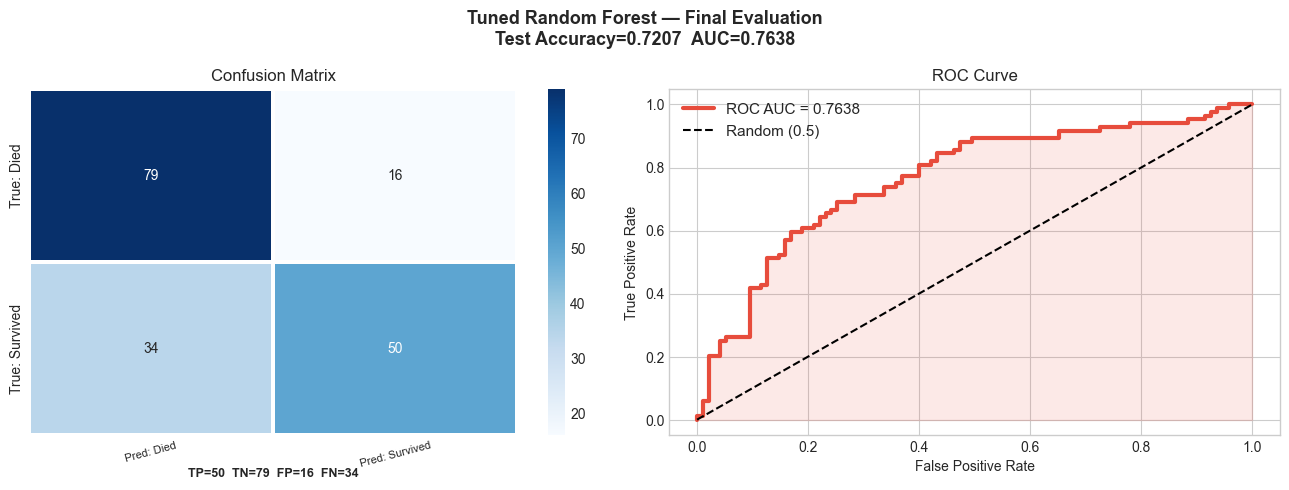

💾 Saved: tt_07_final_evaluation.png


In [ ]:

from sklearn.metrics import roc_curve, roc_auc_score
rf_prob = rf_gs.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, rf_prob)
auc = roc_auc_score(y_test, rf_prob)
cm  = confusion_matrix(y_test, rf_best_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f'Tuned Random Forest — Final Evaluation\nTest Accuracy={rf_best_acc:.4f}  AUC={auc:.4f}',
    fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            linewidths=1.5, linecolor='white',
            xticklabels=['Pred: Died','Pred: Survived'],
            yticklabels=['True: Died','True: Survived'])
axes[0].set_title('Confusion Matrix')
axes[0].tick_params(axis='x', labelsize=8, rotation=15)
tn,fp,fn,tp = cm.ravel()
axes[0].text(0.5,-0.12, f'TP={tp}  TN={tn}  FP={fp}  FN={fn}',
             transform=axes[0].transAxes, ha='center', fontsize=9, fontweight='bold')

axes[1].plot(fpr, tpr, lw=3, color='#e74c3c', label=f'ROC AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--',lw=1.5, label='Random (0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.12, color='#e74c3c')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=11)


plt.tight_layout()
plt.savefig('tt_07_final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: tt_07_final_evaluation.png')


---
## Step 12: Predict Any Passenger

In [29]:
def predict_survival(pclass, sex, age, sibsp, parch, fare, embarked='S',
                     cabin='', model=None):
    """
    Predict Titanic survival for a passenger.

    Examples:
        predict_survival(1, 'female', 28, 0, 0, 120, cabin='C85')  → Rose
        predict_survival(3, 'male',   22, 1, 0,   7)               → Jack
    """
    if model is None: model = rf_gs

    # Build a minimal row and run through engineer_features
    title_guess = 'Mrs.' if sex=='female' and age>=18 else \
                  'Miss.' if sex=='female' else \
                  'Master.' if sex=='male' and age<13 else 'Mr.'
    raw = pd.DataFrame([{
        'PassengerId': 9999, 'Survived': -1, 'Pclass': pclass,
        'Name': f'Test, {title_guess} Passenger',
        'Sex': sex, 'Age': age, 'SibSp': sibsp, 'Parch': parch,
        'Ticket': '999999', 'Fare': fare, 'Cabin': cabin, 'Embarked': embarked
    }])
    raw_fe = engineer_features(raw)
    X_pred = raw_fe[NUM_FEATS + CAT_FEATS]
    prob   = model.predict_proba(X_pred)[0,1]
    pred   = int(prob >= 0.5)

    emoji  = '✅ SURVIVED' if pred==1 else '❌ DID NOT SURVIVE'
    conf   = 'High' if abs(prob-0.5)>0.3 else 'Moderate' if abs(prob-0.5)>0.15 else 'Low'

    print('━'*50)
    print(f'  🚢 TITANIC SURVIVAL PREDICTION')
    print('━'*50)
    print(f'  Class    : {pclass}  |  Sex: {sex}  |  Age: {age}')
    print(f'  Family   : {sibsp} siblings/spouses  +  {parch} parents/children')
    print(f'  Fare     : ${fare:.2f}  |  Embarked: {embarked}')
    print(f'  Cabin    : {cabin if cabin else "None"}')
    print('━'*50)
    print(f'  Probability  : {prob*100:.1f}% chance of survival')
    print(f'  Prediction   : {emoji}')
    print(f'  Confidence   : {conf}')
    print('━'*50)
    return prob, pred


print('=== Rose (1st class, female) ===')
p_rose = predict_survival(1, 'female', 17, 1, 2, 263.0, cabin='C65')

print('\n=== Jack (3rd class, male) ===')
p_jack = predict_survival(3, 'male', 20, 0, 0, 7.25)

print('\n=== Captain (1st class, male, elderly) ===')
p_cap = predict_survival(1, 'male', 62, 0, 0, 135.0, cabin='A36')

=== Rose (1st class, female) ===
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🚢 TITANIC SURVIVAL PREDICTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Class    : 1  |  Sex: female  |  Age: 17
  Family   : 1 siblings/spouses  +  2 parents/children
  Fare     : $263.00  |  Embarked: S
  Cabin    : C65
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Probability  : 76.7% chance of survival
  Prediction   : ✅ SURVIVED
  Confidence   : Moderate
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

=== Jack (3rd class, male) ===
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🚢 TITANIC SURVIVAL PREDICTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Class    : 3  |  Sex: male  |  Age: 20
  Family   : 0 siblings/spouses  +  0 parents/children
  Fare     : $7.25  |  Embarked: S
  Cabin    : None
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Probability  : 25.2% chance of survival
  Prediction   : ❌ DID NOT SURVIVE
  Confidence   : Moderate
━━━━━━━━━━━━━━


**GitHub README should include:**
- `tt_02_engineered_features.png` — shows you can extract features from messy data
- `tt_03_tuning_impact.png` — shows clear improvement from tuning
- `tt_04_learning_curve.png` — shows you understand bias-variance tradeoff
- `tt_06_gridsearch_heatmap.png` — shows systematic hyperparameter search
- Feature engineering table (the markdown table at the top of this notebook)